In [1]:
import pandas as pd   # Librería para manejar tablas (DataFrames)
df = pd.read_csv("train.csv") # Datos crudos: series de precios de los activos (una columna por activo).
df

,date_id,LME_AH_Close,LME_CA_Close,LME_PB_Close,LME_ZS_Close,JPX_Gold_Mini_Futures_Open,JPX_Gold_Rolling-Spot_Futures_Open,JPX_Gold_Standard_Futures_Open,JPX_Platinum_Mini_Futures_Open,JPX_Platinum_Standard_Futures_Open,...,FX_GBPCAD,FX_CADCHF,FX_NZDCAD,FX_NZDCHF,FX_ZAREUR,FX_NOKGBP,FX_NOKCHF,FX_ZARCHF,FX_NOKJPY,FX_ZARGBP
0,0,2264.5,7205.0,2570.0,3349.0,NaN,NaN,NaN,NaN,NaN,...,1.699987,0.776874,0.888115,0.689954,0.066653,0.090582,0.119630,0.078135,13.822740,0.059163
1,1,2228.0,7147.0,2579.0,3327.0,NaN,NaN,NaN,NaN,NaN,...,1.695279,0.778682,0.889488,0.692628,0.067354,0.091297,0.120520,0.079066,13.888146,0.059895
2,2,2250.0,7188.5,2587.0,3362.0,4684.0,4691.0,4684.0,3363.0,3367.0,...,1.692724,0.780186,0.894004,0.697490,0.067394,0.091478,0.120809,0.079287,13.983675,0.060037
3,3,2202.5,7121.0,2540.0,3354.0,4728.0,4737.0,4729.0,3430.0,3426.0,...,1.683111,0.785329,0.889439,0.698502,0.067639,0.091558,0.121021,0.079285,14.035571,0.059983
4,4,2175.0,7125.0,2604.0,3386.0,NaN,NaN,NaN,NaN,NaN,...,1.684816,0.787264,0.891042,0.701485,0.067443,0.091266,0.121055,0.078925,14.013760,0.059503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1956,1956,2629.5,9778.5,2010.0,2818.5,16041.0,16183.0,16046.0,6076.0,6073.0,...,1.842075,0.584336,0.819066,0.478610,0.048581,0.073181,0.078771,0.045312,14.606239,0.042097
1957,1957,2646.5,9860.0,2014.5,2838.5,NaN,NaN,NaN,NaN,NaN,...,1.844791,0.583610,0.816264,0.476380,0.048547,0.072941,0.078532,0.045315,14.502889,0.042089
1958,1958,2658.5,9919.5,2011.0,2860.0,16132.5,16261.0,16134.0,6200.0,6200.0,...,1.839538,0.583402,0.816093,0.476110,0.048495,0.073421,0.078794,0.045184,14.580416,0.042103
1959,1959,2651.0,9930.5,2032.0,2862.0,16214.5,16341.0,16211.0,6175.0,6195.0,...,1.847106,0.582341,0.822465,0.478955,0.048457,0.072909,0.078424,0.045193,14.492839,0.042015


In [2]:
import re
from collections import defaultdict

CATEGORY_MAP = {
    # Energía (oil & gas)
    "COP": ["energy"], "MPC": ["energy"], "DVN": ["energy"],
    "CVX": ["energy"], "CVE": ["energy"], "BP":  ["energy"],
    "BKR": ["energy"], "WMB": ["energy"],

    # Oro / metales preciosos
    "GLD": ["gold"], "NEM": ["gold"],

    # Materiales / metales industriales (proxy sectorial)
    "XLB": ["materials"],

    # Tasas / bonos (drivers macro; útiles para oro/energía)
    "IEF": ["rates"], "BND": ["rates"], "AGG": ["rates"],

    # Crédito
    "JNK": ["credit"], "VCIT": ["credit"], "EMB": ["credit_emerging"],

    # Asia / demanda manufacturera
    "EWJ": ["asia_equity"],

    # Bancos (condiciones financieras; factor macro)
    "MS": ["financials"], "BCS": ["financials"],
}

# === 2) Helper: extraer el ticker desde 'US_Stock_<TICKER>_adj_volume' ===
TICKER_REGEX = re.compile(r"US_Stock_(?P<ticker>[A-Z]+)_adj_close$", re.IGNORECASE)

def extract_ticker(colname: str) -> str | None:
    m = TICKER_REGEX.search(colname)
    if not m: 
        return None
    return m.group("ticker").upper()

# === 3) Función principal de categorización ===
def categorize_columns(columns):
    categories = defaultdict(list)
    unknown = []
    tickers = {}

    for c in columns:
        t = extract_ticker(c)
        tickers[c] = t
        if t is None:
            unknown.append(c)
            continue
        cats = CATEGORY_MAP.get(t)
        if not cats:
            unknown.append(c)
        else:
            for cat in cats:
                categories[cat].append(c)
    categories = {k: sorted(v) for k, v in categories.items()}
    unknown = sorted(unknown)
    return categories, unknown, tickers

def categorize_df(df):
    return categorize_columns(df.columns)

In [3]:
cats, unknown, tickers = categorize_df(df)

print("Categorías detectadas:")
for k, v in cats.items():
    print(f"  - {k}: {len(v)} cols")

if unknown:
    print("\nNo mapeadas (revisa si quieres agregarlas al mapa):")
    for c in unknown:
        print("  ", c)

Categorías detectadas:
  - rates: 3 cols
  - financials: 2 cols
  - energy: 8 cols
  - credit_emerging: 1 cols
  - asia_equity: 1 cols
  - gold: 2 cols
  - credit: 2 cols
  - materials: 1 cols

No mapeadas (revisa si quieres agregarlas al mapa):
   FX_AUDCAD
   FX_AUDCHF
   FX_AUDJPY
   FX_AUDNZD
   FX_AUDUSD
   FX_CADCHF
   FX_CADJPY
   FX_CADUSD
   FX_CHFJPY
   FX_EURAUD
   FX_EURCAD
   FX_EURCHF
   FX_EURGBP
   FX_EURJPY
   FX_EURNZD
   FX_EURUSD
   FX_GBPAUD
   FX_GBPCAD
   FX_GBPCHF
   FX_GBPJPY
   FX_GBPNZD
   FX_GBPUSD
   FX_NOKCHF
   FX_NOKEUR
   FX_NOKGBP
   FX_NOKJPY
   FX_NOKUSD
   FX_NZDCAD
   FX_NZDCHF
   FX_NZDJPY
   FX_NZDUSD
   FX_USDCHF
   FX_USDJPY
   FX_ZARCHF
   FX_ZAREUR
   FX_ZARGBP
   FX_ZARJPY
   FX_ZARUSD
   JPX_Gold_Mini_Futures_Close
   JPX_Gold_Mini_Futures_High
   JPX_Gold_Mini_Futures_Low
   JPX_Gold_Mini_Futures_Open
   JPX_Gold_Mini_Futures_Volume
   JPX_Gold_Mini_Futures_open_interest
   JPX_Gold_Mini_Futures_settlement_price
   JPX_Gold_Rolling-Spot_Fu

In [4]:
import numpy as np
import pandas as pd

# ---------- 1) Conversión robusta a numérico ----------
def robust_to_numeric(s: pd.Series) -> pd.Series:
    x = s.astype(str).str.strip()
    x = x.str.replace(r"^\((.*)\)$", r"-\1", regex=True)  # (123.4) -> -123.4
    x = x.str.replace("%", "", regex=False)
    x = x.str.replace(",", "", regex=False)
    x = x.replace({"": np.nan, "nan": np.nan, "None": np.nan})
    return pd.to_numeric(x, errors="coerce")

def to_numeric_df(df_in: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=df_in.index)
    for c in df_in.columns:
        out[c] = robust_to_numeric(df_in[c])
    return out

df_num = to_numeric_df(df)   # <<< trabajaremos siempre en numérico

# ---------- 2) Diagnóstico (opcional) ----------
def debug_category(df_num: pd.DataFrame, cols: list[str]):
    rows = []
    for c in cols:
        if c not in df_num.columns:
            rows.append((c, "NO_COL", 0.0, 0.0))
            continue
        s = df_num[c]
        nnr = s.notna().mean()
        stdv = float(s.std(ddof=1)) if nnr > 0 else 0.0
        status = "OK" if stdv > 0 else "CONST_OR_NAN"
        rows.append((c, status, nnr, stdv))
    return pd.DataFrame(rows, columns=["col","status","non_na_ratio","std"]).sort_values(
        ["status","non_na_ratio","std"], ascending=[True, False, False]
    )

# Ejemplo de diagnóstico para ENERGY:
# display(debug_category(df_num, cats.get("energy", [])))

# ---------- 3) Selector con cascada de fallback (SIN PCA) ----------
def pick_rep_fallback(df_num: pd.DataFrame, cols: list[str], min_non_na_ratio: float = 0.05):
    cols = [c for c in cols if c in df_num.columns]
    if not cols:
        return None, {"reason": "no cols in df"}

    metrics = []
    for c in cols:
        s = df_num[c]
        nnr = s.notna().mean()
        stdv = float(s.std(ddof=1)) if nnr > 0 else 0.0
        metrics.append((c, nnr, stdv))
    met = pd.DataFrame(metrics, columns=["col","non_na_ratio","std"])

    # 1) suficiente cobertura + std>0
    cand = met[(met["non_na_ratio"] >= min_non_na_ratio) & (met["std"] > 0)]
    if not cand.empty:
        best = cand.sort_values(["std","non_na_ratio"], ascending=False).iloc[0]["col"]
        return best, {"criterion": "std_with_coverage", "table": met}

    # 2) mayor std aunque cobertura sea baja
    cand2 = met[met["std"] > 0]
    if not cand2.empty:
        best = cand2.sort_values(["std","non_na_ratio"], ascending=False).iloc[0]["col"]
        return best, {"criterion": "std_any_coverage", "table": met}

    # 3) mayor cobertura (aunque std==0)
    cand3 = met.sort_values(["non_na_ratio"], ascending=False)
    if not cand3.empty and cand3.iloc[0]["non_na_ratio"] > 0:
        best = cand3.iloc[0]["col"]
        return best, {"criterion": "max_non_na_ratio", "table": met}

    # 4) último recurso: primera columna
    return cols[0], {"criterion": "first_col_fallback", "table": met}

def pick_representatives_no_pca_robust(df_num: pd.DataFrame, categories: dict[str, list[str]],
                                       min_non_na_ratio: float = 0.05):
    rep_map, details = {}, {}
    for cat, cols in categories.items():
        best, info = pick_rep_fallback(df_num, cols, min_non_na_ratio=min_non_na_ratio)
        rep_map[cat] = best
        details[cat] = info
    # DataFrame reducido: 1 columna por categoría (renombrada con el nombre de la categoría)
    rep_cols = {cat: col for cat, col in rep_map.items() if col is not None}
    rep_df = pd.DataFrame({cat: df_num[col] for cat, col in rep_cols.items()})
    return rep_map, rep_df, details

# ---------- 4) Ejecutar sobre tus categorías detectadas ----------
cats, unknown, tickers = categorize_df(df)   # (si ya tienes cats, puedes omitir esta línea)
rep_map, reps_df, details = pick_representatives_no_pca_robust(df_num, cats, min_non_na_ratio=0.05)

print("Representantes por categoría (SIN PCA):")
for k, v in rep_map.items():
    print(f"{k:>15} -> {v}")

C:\Users\jemil\AppData\Local\Temp\ipykernel_15244\3893418418.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[c] = robust_to_numeric(df_in[c])
C:\Users\jemil\AppData\Local\Temp\ipykernel_15244\3893418418.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[c] = robust_to_numeric(df_in[c])
C:\Users\jemil\AppData\Local\Temp\ipykernel_15244\3893418418.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining 

Representantes por categoría (SIN PCA):
          rates -> US_Stock_IEF_adj_close
     financials -> US_Stock_MS_adj_close
         energy -> US_Stock_MPC_adj_close
credit_emerging -> US_Stock_EMB_adj_close
    asia_equity -> US_Stock_EWJ_adj_close
           gold -> US_Stock_GLD_adj_close
         credit -> US_Stock_JNK_adj_close
      materials -> US_Stock_XLB_adj_close


C:\Users\jemil\AppData\Local\Temp\ipykernel_15244\3893418418.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[c] = robust_to_numeric(df_in[c])
C:\Users\jemil\AppData\Local\Temp\ipykernel_15244\3893418418.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[c] = robust_to_numeric(df_in[c])
C:\Users\jemil\AppData\Local\Temp\ipykernel_15244\3893418418.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining 

In [5]:
reps_df

,rates,financials,energy,credit_emerging,asia_equity,gold,credit,materials
0,89.761300,41.6019,52.8379,82.036500,53.248900,125.15,69.775800,53.011300
1,89.855100,41.7135,53.9627,82.001300,53.982000,124.82,70.117400,53.382600
2,89.812400,42.3512,54.0177,82.212700,54.644400,125.46,70.212300,53.848900
3,89.701500,42.3352,54.5368,82.262000,54.794500,125.33,70.288300,54.280700
4,89.658900,42.1599,54.5761,82.114000,55.112500,125.31,70.212300,54.358400
...,...,...,...,...,...,...,...,...
1956,95.011400,140.8300,174.2100,92.683171,72.391468,308.39,97.785611,90.679470
1957,95.343538,140.4700,174.8800,93.036192,73.197946,313.13,97.917071,91.141812
1958,95.615286,140.0400,175.2500,93.197573,73.570942,316.10,98.099092,92.398178
1959,95.273084,142.2100,177.5400,93.237919,77.109363,312.18,98.169877,92.709757


# Nuevo EDA - EDA reps_df

# Modelados reps_df

## GRU

In [7]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ============================================================
# === FUNCION GENERAL: entrena y evalúa GRU para una serie ===
# ============================================================
def train_gru_univariate(
    series: pd.Series,
    win_size: int = 30,
    epochs: int = 100,
    batch_size: int = 64,
    lr: float = 1e-3,
    patience: int = 10,
    train_split: float = 0.8
):
    """
    Entrena un modelo GRU univariante sobre una serie temporal de precios.

    Devuelve:
      - metrics: dict con RMSE y MAE sobre retornos
      - pred_df: DataFrame con precios reales y predichos
    """
    # --- 1) Preprocesamiento ---
    series = series.dropna().astype(float)
    if len(series) < win_size + 10:
        raise ValueError("Serie demasiado corta para entrenar")

    # Retornos log
    rets = np.log(series).diff().dropna()

    # Train/test split
    split = int(len(rets) * train_split)
    y_train, y_test = rets.iloc[:split], rets.iloc[split:]

    # --- 2) Crear ventanas ---
    def make_windows(y, win):
        Xs, ys = [], []
        yv = y.values.astype(np.float32)
        for t in range(len(yv) - win):
            Xs.append(yv[t:t+win])
            ys.append(yv[t+win])
        return np.array(Xs)[:, :, None], np.array(ys).astype(np.float32)

    Xtr, ytr = make_windows(y_train, win_size)
    Xte, yte = make_windows(y_test, win_size)

    # --- 3) Modelo GRU simple ---
    class GRUUni(nn.Module):
        def __init__(self, hidden=64, dropout=0.2):
            super().__init__()
            self.gru = nn.GRU(input_size=1, hidden_size=hidden, batch_first=True)
            self.drop = nn.Dropout(dropout)
            self.fc1 = nn.Linear(hidden, 32)
            self.act = nn.ReLU()
            self.fc2 = nn.Linear(32, 1)
        def forward(self, x):
            out, _ = self.gru(x)
            last = out[:, -1, :]
            z = self.drop(last)
            z = self.act(self.fc1(z))
            return self.fc2(z)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = GRUUni().to(device)
    loss_fn = nn.MSELoss()
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    # DataLoaders
    train_dl = DataLoader(TensorDataset(torch.tensor(Xtr), torch.tensor(ytr)[:, None]),
                          batch_size=batch_size, shuffle=True)
    val_dl   = DataLoader(TensorDataset(torch.tensor(Xte), torch.tensor(yte)[:, None]),
                          batch_size=batch_size, shuffle=False)

    # --- 4) Entrenamiento con early stopping ---
    best_loss, wait, best_state = float("inf"), 0, None
    for ep in range(epochs):
        model.train()
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()

        # validación
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(device), yb.to(device)
                val_loss += loss_fn(model(xb), yb).item() * len(xb)
        val_loss /= len(val_dl.dataset)

        if val_loss < best_loss - 1e-9:
            best_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    # Recuperar mejor modelo
    model.load_state_dict(best_state)

    # --- 5) Predicción y métricas ---
    model.eval()
    with torch.no_grad():
        pred = model(torch.tensor(Xte).to(device)).cpu().numpy().ravel()

    rmse = np.sqrt(mean_squared_error(yte, pred))
    mae = mean_absolute_error(yte, pred)
    metrics = {"RMSE_ret": rmse, "MAE_ret": mae}

    # --- 6) Reconstrucción de precios ---
    # Precio base = último precio antes del primer test
    base_price = series.iloc[split + win_size - 1]
    price_true = base_price * np.exp(np.cumsum(yte))
    price_pred = base_price * np.exp(np.cumsum(pred))

    # Índices para las predicciones
    idx_start = rets.index[split + win_size : split + win_size + len(pred)]
    pred_df = pd.DataFrame({
        "price_true": price_true,
        "price_pred": price_pred
    }, index=idx_start)

    return metrics, pred_df


=== Entrenando GRU para: rates ===
RMSE_ret = 0.004102, MAE_ret = 0.003287


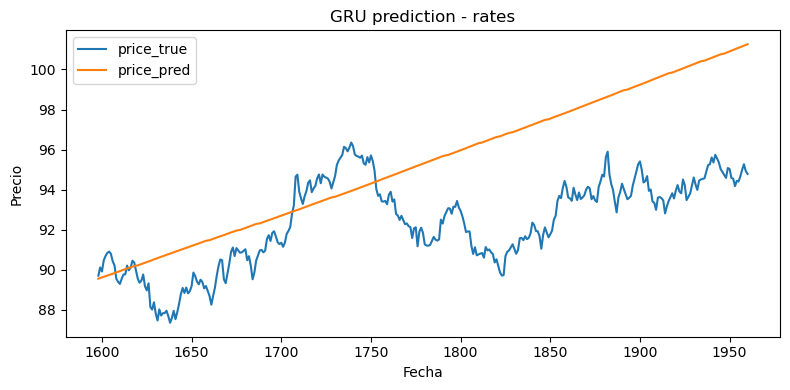


=== Entrenando GRU para: financials ===
RMSE_ret = 0.019626, MAE_ret = 0.012765


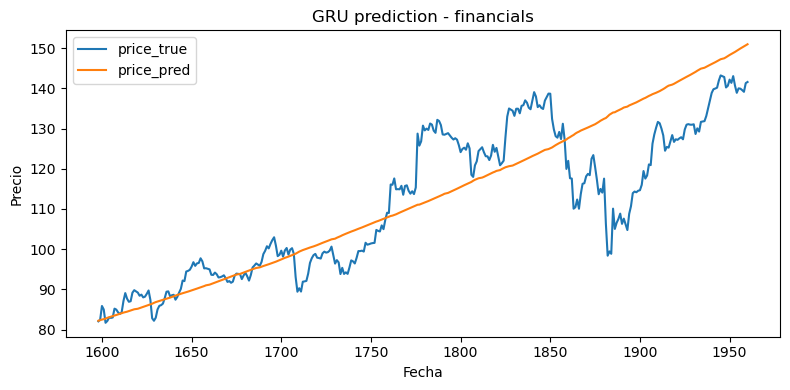


=== Entrenando GRU para: energy ===
RMSE_ret = 0.021585, MAE_ret = 0.014729


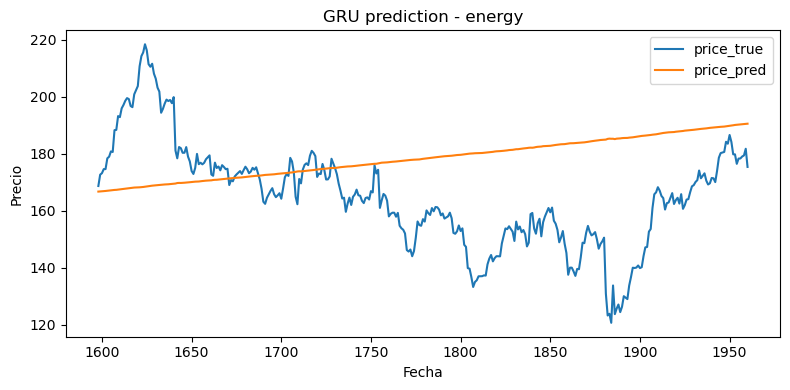


=== Entrenando GRU para: credit_emerging ===
RMSE_ret = 0.004640, MAE_ret = 0.003411


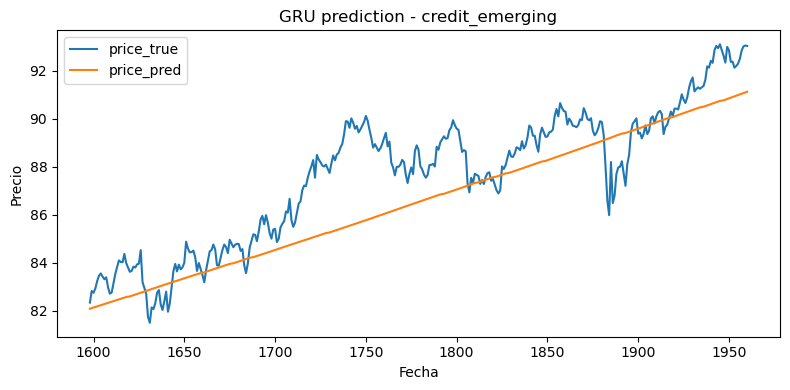


=== Entrenando GRU para: asia_equity ===
RMSE_ret = 0.012717, MAE_ret = 0.009163


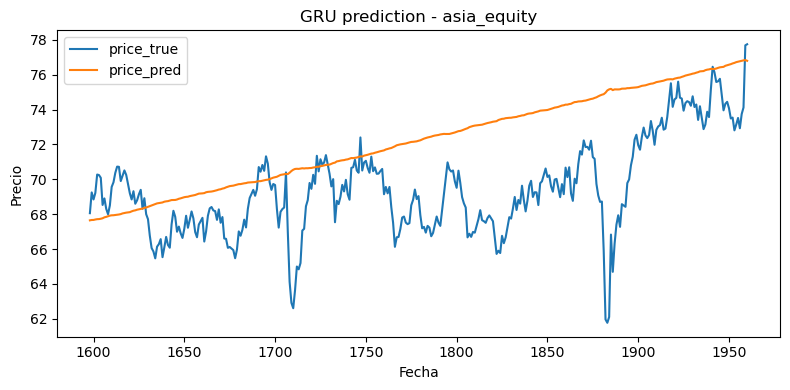


=== Entrenando GRU para: gold ===
RMSE_ret = 0.011088, MAE_ret = 0.008421


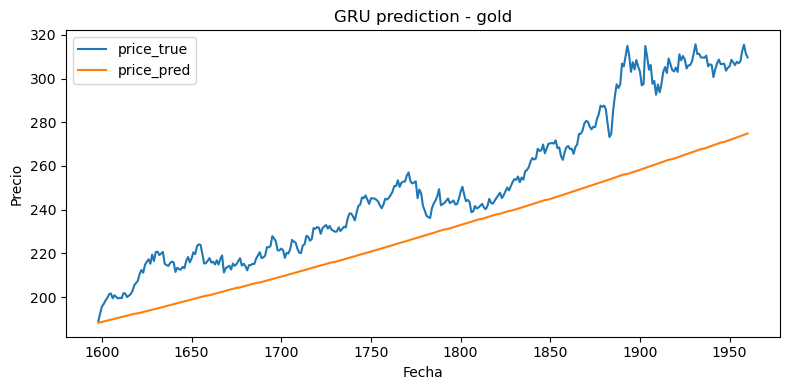


=== Entrenando GRU para: credit ===
RMSE_ret = 0.003512, MAE_ret = 0.002371


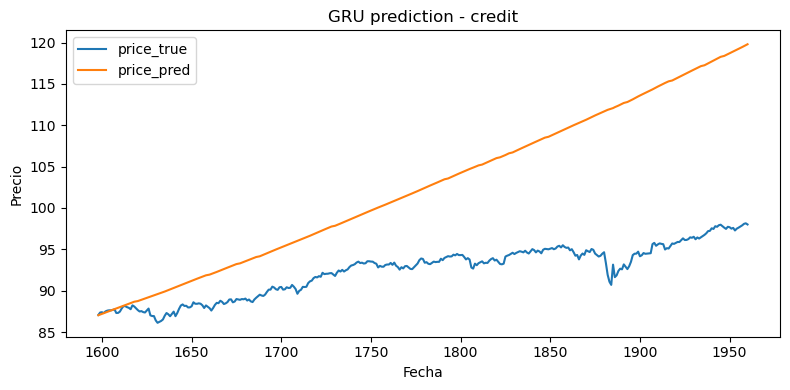


=== Entrenando GRU para: materials ===
RMSE_ret = 0.011345, MAE_ret = 0.007958


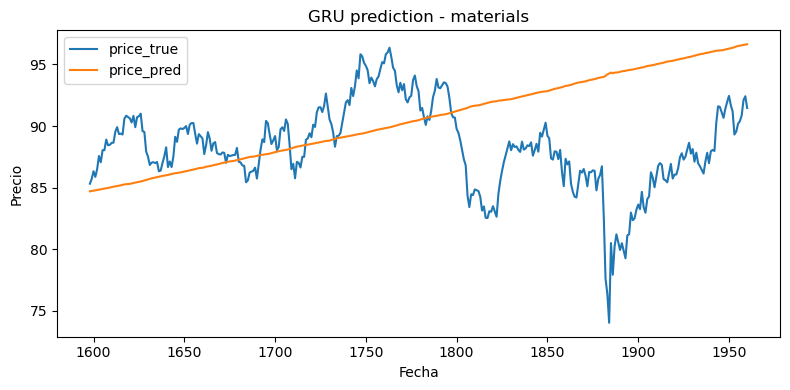


Resumen global de métricas:


,RMSE_ret,MAE_ret
credit,0.003512,0.002371
rates,0.004102,0.003287
credit_emerging,0.004640,0.003411
gold,0.011088,0.008421
materials,0.011345,0.007958
asia_equity,0.012717,0.009163
financials,0.019626,0.012765
energy,0.021585,0.014729


In [10]:
import matplotlib.pyplot as plt

all_metrics = {}
all_predictions = {}

for col in reps_df.columns:
    print(f"\n=== Entrenando GRU para: {col} ===")
    series = reps_df[col]

    # Saltar si la serie es demasiado corta o vacía
    if series.dropna().shape[0] < 50:
        print(f"Serie '{col}' demasiado corta, se omite.")
        continue

    try:
        metrics, pred_df = train_gru_univariate(series, win_size=30)
        all_metrics[col] = metrics
        all_predictions[col] = pred_df

        # Mostrar métricas resumidas
        print(f"RMSE_ret = {metrics['RMSE_ret']:.6f}, MAE_ret = {metrics['MAE_ret']:.6f}")

        # Graficar resultado
        pred_df.plot(title=f"GRU prediction - {col}", figsize=(8,4))
        plt.xlabel("Fecha")
        plt.ylabel("Precio")
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error con {col}: {e}")
        continue

# ---- Resumen general ----
metrics_df = pd.DataFrame(all_metrics).T.sort_values("RMSE_ret")
print("\nResumen global de métricas:")
display(metrics_df)

# Modelo 2

Modelo para LME_AH_Close:
MAE: 1.7425523795182434
MSE: 6.332647421225808

Modelo para LME_CA_Close:
MAE: 7.602800603166714
MSE: 965.4076843000778

Modelo para LME_PB_Close:
MAE: 0.4609603527141693
MSE: 0.3631550371179749

Modelo para LME_ZS_Close:
MAE: 1.1447895822563996
MSE: 3.0751183143044893

Modelo para JPX_Gold_Mini_Futures_Open:
MAE: 3213.060614492225
MSE: 13533462.237136286

Modelo para JPX_Gold_Standard_Futures_Open:
MAE: 3209.321463070943
MSE: 13511701.057353113

Modelo para JPX_Platinum_Mini_Futures_Open:
MAE: 207.0404034712452
MSE: 175423.35855190744

Modelo para JPX_Platinum_Standard_Futures_Open:
MAE: 205.57602980069814
MSE: 173539.66506842113



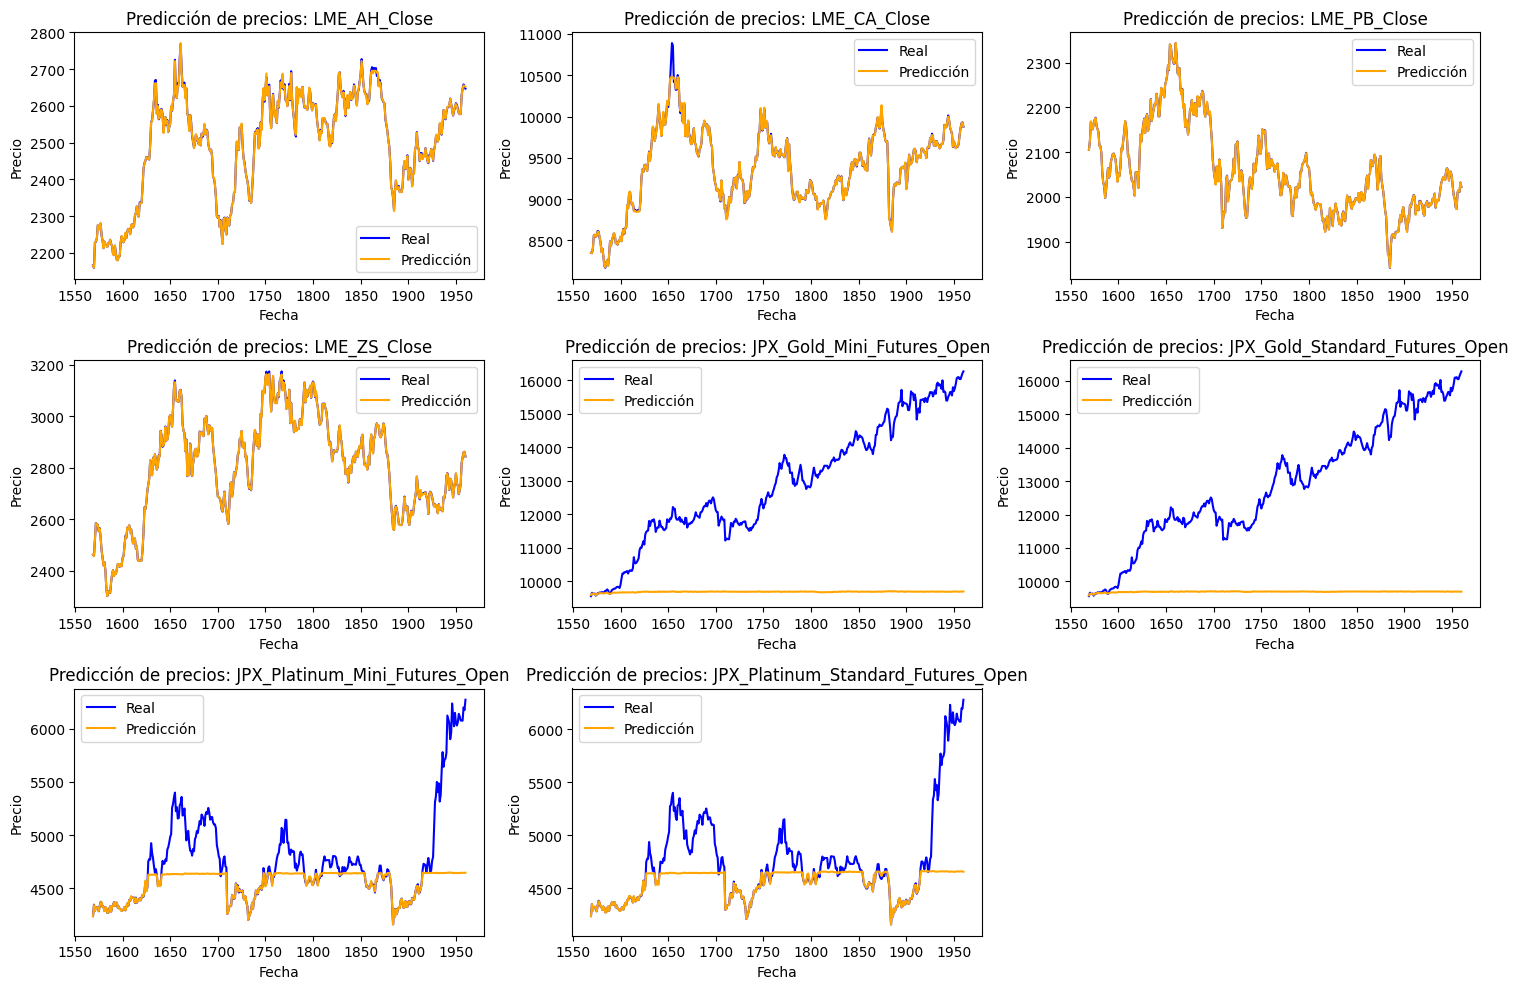

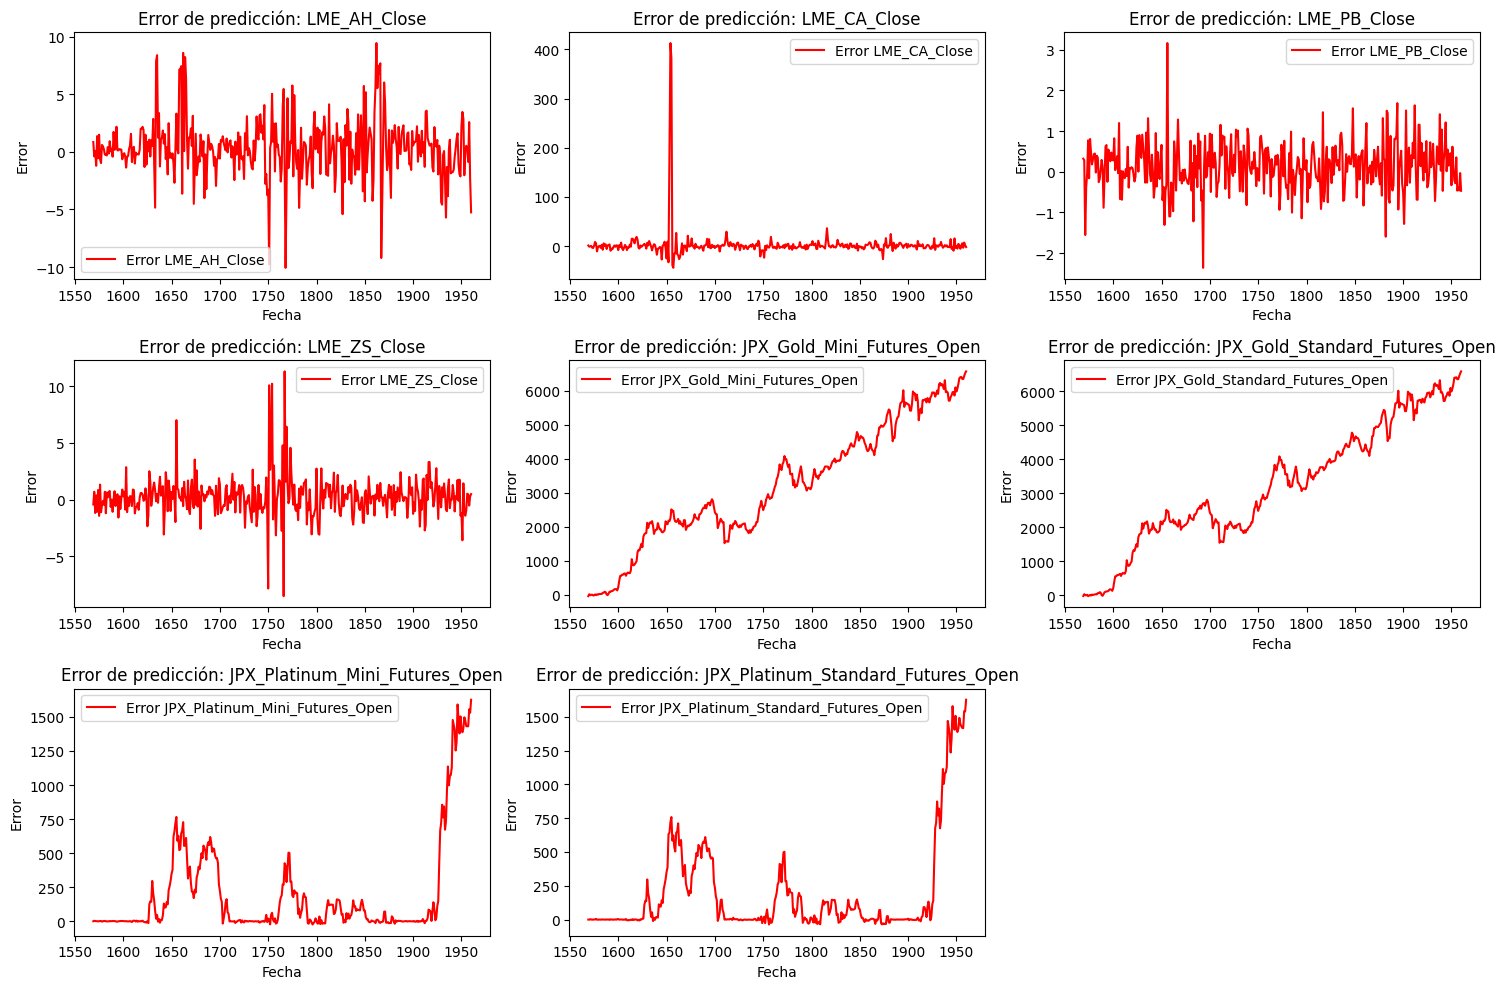

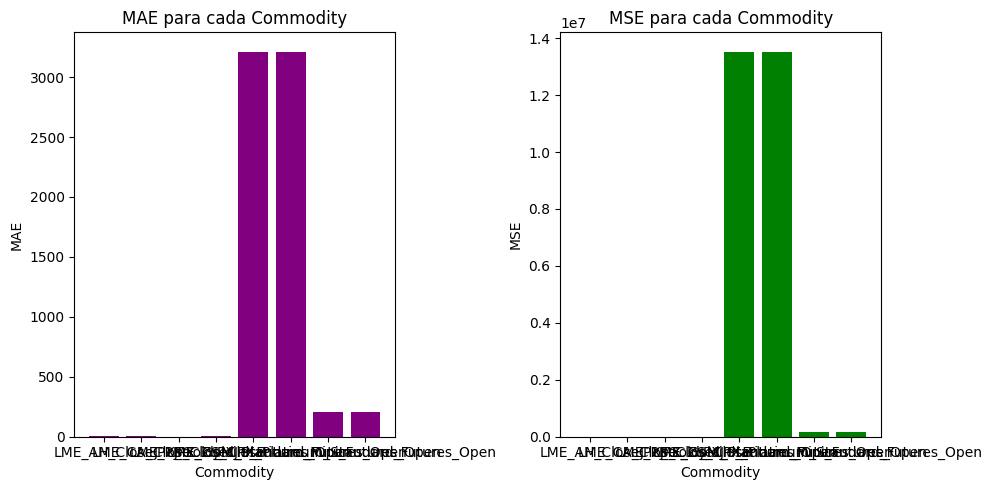

In [20]:
# Primero importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

# Cargar el dataset
df = pd.read_csv('train.csv')  # Asegúrate de tener la ruta correcta de tu archivo CSV

# Limpiar y preprocesar los datos (eliminación de NaN y transformaciones)
df.ffill(inplace=True)  # Mejor uso de 'ffill' para evitar la advertencia futura

# Asegurarse de que las columnas de precios sean numéricas
columns_to_predict = ['LME_AH_Close', 'LME_CA_Close', 'LME_PB_Close', 'LME_ZS_Close', 
                      'JPX_Gold_Mini_Futures_Open', 'JPX_Gold_Standard_Futures_Open', 
                      'JPX_Platinum_Mini_Futures_Open', 'JPX_Platinum_Standard_Futures_Open']

# Convertir todas las columnas a numéricas, forzando la conversión de valores no numéricos a NaN
df[columns_to_predict] = df[columns_to_predict].apply(pd.to_numeric, errors='coerce')

# Reemplazar valores NaN por el promedio de cada columna
df[columns_to_predict] = df[columns_to_predict].fillna(df[columns_to_predict].mean())

# Crear características para la predicción (lag de 5 días)
def create_features(df, target_column, lag=1):
    df_copy = df.copy()
    for i in range(1, lag + 1):
        df_copy[f'lag_{i}'] = df_copy[target_column].shift(i)
    df_copy.dropna(inplace=True)
    return df_copy

# Inicializar diccionarios para almacenar resultados
models = {}
predictions = {}
mae_scores = {}
mse_scores = {}

# Dividir los datos en entrenamiento y prueba (común para todas las columnas)
X = pd.DataFrame()  # Para almacenar todas las características
y = pd.DataFrame()  # Para almacenar todas las etiquetas

for column in columns_to_predict:
    # Crear características y preparar las columnas de datos
    df_features = create_features(df, column, lag=5)
    X = pd.concat([X, df_features.drop(column, axis=1)], axis=1)
    y[column] = df_features[column]

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Crear el modelo Random Forest y entrenar con optimizaciones
for column in columns_to_predict:
    # Crear el modelo con los parámetros optimizados
    model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train[column])

    # Realizar predicciones
    y_pred = model.predict(X_test)
    predictions[column] = y_pred
    
    # Evaluar el modelo
    mae = mean_absolute_error(y_test[column], y_pred)
    mse = mean_squared_error(y_test[column], y_pred)
    
    mae_scores[column] = mae
    mse_scores[column] = mse
    
    # Guardar el modelo
    models[column] = model

    # Imprimir las métricas de evaluación
    print(f"Modelo para {column}:")
    print(f"MAE: {mae}")
    print(f"MSE: {mse}\n")

# Graficar los resultados para cada commodity
plt.figure(figsize=(15, 10))

for i, column in enumerate(columns_to_predict, 1):
    plt.subplot(3, 3, i)
    plt.plot(y_test.index, y_test[column], label='Real', color='blue')
    plt.plot(y_test.index, predictions[column], label='Predicción', color='orange')
    plt.title(f"Predicción de precios: {column}")
    plt.xlabel('Fecha')
    plt.ylabel('Precio')
    plt.legend()

plt.tight_layout()
plt.show()

# Graficar los errores de predicción
plt.figure(figsize=(15, 10))

for i, column in enumerate(columns_to_predict, 1):
    plt.subplot(3, 3, i)
    plt.plot(y_test.index, y_test[column] - predictions[column], label=f'Error {column}', color='red')
    plt.title(f"Error de predicción: {column}")
    plt.xlabel('Fecha')
    plt.ylabel('Error')
    plt.legend()

plt.tight_layout()
plt.show()

# Graficar las métricas MAE y MSE
plt.figure(figsize=(10, 5))

# MAE
plt.subplot(1, 2, 1)
plt.bar(mae_scores.keys(), mae_scores.values(), color='purple')
plt.title('MAE para cada Commodity')
plt.xlabel('Commodity')
plt.ylabel('MAE')

# MSE
plt.subplot(1, 2, 2)
plt.bar(mse_scores.keys(), mse_scores.values(), color='green')
plt.title('MSE para cada Commodity')
plt.xlabel('Commodity')
plt.ylabel('MSE')

plt.tight_layout()
plt.show()


# Modelo 3

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

# Cargar el dataset
df = pd.read_csv('train.csv')  # Asegúrate de tener la ruta correcta de tu archivo CSV

# Limpiar y preprocesar los datos (eliminación de NaN y transformaciones)
df.ffill(inplace=True)  # Mejor uso de 'ffill' para evitar la advertencia futura

# Asegurarse de que las columnas de precios sean numéricas
columns_to_predict = ['LME_AH_Close', 'LME_CA_Close', 'LME_PB_Close', 'LME_ZS_Close', 
                      'JPX_Gold_Mini_Futures_Open', 'JPX_Gold_Standard_Futures_Open', 
                      'JPX_Platinum_Mini_Futures_Open', 'JPX_Platinum_Standard_Futures_Open']

# Convertir todas las columnas a numéricas, forzando la conversión de valores no numéricos a NaN
df[columns_to_predict] = df[columns_to_predict].apply(pd.to_numeric, errors='coerce')

# Reemplazar valores NaN por el promedio de cada columna
df[columns_to_predict] = df[columns_to_predict].fillna(df[columns_to_predict].mean())

# Crear características para la predicción (lag de 5 días)
def create_features(df, target_column, lag=1):
    df_copy = df.copy()
    for i in range(1, lag + 1):
        df_copy[f'lag_{i}'] = df_copy[target_column].shift(i)
    df_copy.dropna(inplace=True)
    return df_copy

# Inicializar diccionarios para almacenar resultados
models = {}
predictions = {}
mae_scores = {}
mse_scores = {}

# Dividir los datos en entrenamiento y prueba (común para todas las columnas)
X = pd.DataFrame()  # Para almacenar todas las características
y = pd.DataFrame()  # Para almacenar todas las etiquetas

for column in columns_to_predict:
    # Crear características y preparar las columnas de datos
    df_features = create_features(df, column, lag=5)
    X = pd.concat([X, df_features.drop(column, axis=1)], axis=1)
    y[column] = df_features[column]

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Normalizar los datos para LSTM (escala entre 0 y 1)
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X)

# Remodelar los datos para LSTM (LSTM espera datos en 3D)
X_scaled = X_scaled.reshape((X_scaled.shape[0], X_scaled.shape[1], 1))  # LSTM espera datos en 3D

# Crear el modelo LSTM para cada commodity
for column in columns_to_predict:
    # Crear el modelo LSTM
    model_lstm = Sequential()
    model_lstm.add(LSTM(units=50, return_sequences=True, input_shape=(X_scaled.shape[1], 1)))
    model_lstm.add(LSTM(units=50, return_sequences=False))
    model_lstm.add(Dense(units=1))  # Capa de salida (predicción de precios)

    # Compilar el modelo
    model_lstm.compile(optimizer='adam', loss='mean_squared_error')

    # Entrenar el modelo
    model_lstm.fit(X_scaled, y[column], epochs=50, batch_size=32)

    # Realizar predicciones
    y_pred_lstm = model_lstm.predict(X_scaled)

    # Evaluar el modelo
    mae_lstm = mean_absolute_error(y[column], y_pred_lstm)
    mse_lstm = mean_squared_error(y[column], y_pred_lstm)

    # Almacenar las predicciones y métricas
    predictions[column] = y_pred_lstm
    mae_scores[column] = mae_lstm
    mse_scores[column] = mse_lstm

    # Guardar el modelo
    models[column] = model_lstm

    # Imprimir las métricas de evaluación
    print(f"Modelo LSTM para {column}:")
    print(f"MAE: {mae_lstm}")
    print(f"MSE: {mse_lstm}\n")

# Graficar los resultados para cada commodity
plt.figure(figsize=(15, 10))

for i, column in enumerate(columns_to_predict, 1):
    plt.subplot(3, 3, i)
    plt.plot(y_test.index, y_test[column], label='Real', color='blue')
    plt.plot(y_test.index, predictions[column], label='Predicción', color='orange')
    plt.title(f"Predicción de precios: {column}")
    plt.xlabel('Fecha')
    plt.ylabel('Precio')
    plt.legend()

plt.tight_layout()
plt.show()

# Graficar los errores de predicción
plt.figure(figsize=(15, 10))

for i, column in enumerate(columns_to_predict, 1):
    plt.subplot(3, 3, i)
    plt.plot(y_test.index, y_test[column] - predictions[column], label=f'Error {column}', color='red')
    plt.title(f"Error de predicción: {column}")
    plt.xlabel('Fecha')
    plt.ylabel('Error')
    plt.legend()

plt.tight_layout()
plt.show()

# Graficar las métricas MAE y MSE
plt.figure(figsize=(10, 5))

# MAE
plt.subplot(1, 2, 1)
plt.bar(mae_scores.keys(), mae_scores.values(), color='purple')
plt.title('MAE para cada Commodity')
plt.xlabel('Commodity')
plt.ylabel('MAE')

# MSE
plt.subplot(1, 2, 2)
plt.bar(mse_scores.keys(), mse_scores.values(), color='green')
plt.title('MSE para cada Commodity')
plt.xlabel('Commodity')
plt.ylabel('MSE')

plt.tight_layout()
plt.show()


# Modelo 4

Modelo XGBoost

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr

In [ ]:
df = reps_df.copy().reset_index(drop=True)

# calculamos retornos logarítmicos por categoría
rets = np.log(df / df.shift(1))
rets = rets.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

#  definimos la variable objetivo (target)
target_col = "energy"  #  cambiar a 'gold', 'credit', etc.
y = rets[target_col]
X_base = rets.drop(columns=[target_col])

print(f"Variables predictoras: {list(X_base.columns)}")
print(f"Target: {target_col}")

Variables predictoras: ['rates', 'financials', 'credit_emerging', 'asia_equity', 'gold', 'credit', 'materials']
Target: energy


In [18]:
def build_temporal_features(df: pd.DataFrame, lags=[1,2,3,5], windows=[3,5,10]):
    feats = pd.DataFrame(index=df.index)
    for col in df.columns:
        for lag in lags:
            feats[f"{col}_lag{lag}"] = df[col].shift(lag)
        for win in windows:
            feats[f"{col}_mean{win}"] = df[col].rolling(win).mean()
            feats[f"{col}_std{win}"]  = df[col].rolling(win).std()
    return feats

X = build_temporal_features(X_base)
y = y.loc[X.index]
X = X.dropna()
y = y.loc[X.index]

print(f"Shape final de X: {X.shape}, y: {y.shape}")

Shape final de X: (1817, 70), y: (1817,)


In [19]:
tscv = TimeSeriesSplit(n_splits=4)
preds = []
trues = []
dates_idx = []

In [20]:
spearman_scores = []
rmse_scores = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rho = spearmanr(y_test, y_pred).correlation

    rmse_scores.append(rmse)
    spearman_scores.append(rho)

    preds.append(y_pred)
    trues.append(y_test)
    dates_idx.append(test_idx)

    print(f"Fold {fold+1}: Spearman={rho:.3f}, RMSE={rmse:.5f}")

print("\n=== Promedios finales ===")
print(f"Spearman promedio: {np.nanmean(spearman_scores):.3f}")
print(f"RMSE promedio:     {np.mean(rmse_scores):.5f}")

Fold 1: Spearman=0.416, RMSE=0.04227
Fold 2: Spearman=0.425, RMSE=0.02019
Fold 3: Spearman=0.361, RMSE=0.02138
Fold 4: Spearman=0.307, RMSE=0.02127

=== Promedios finales ===
Spearman promedio: 0.377
RMSE promedio:     0.02628


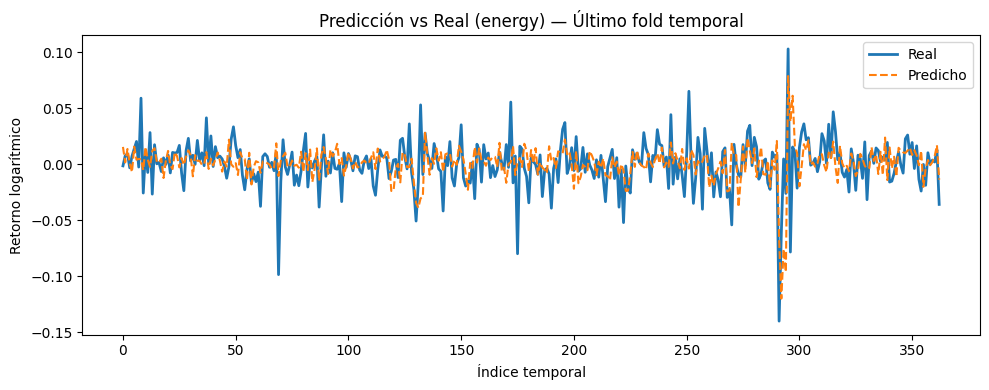

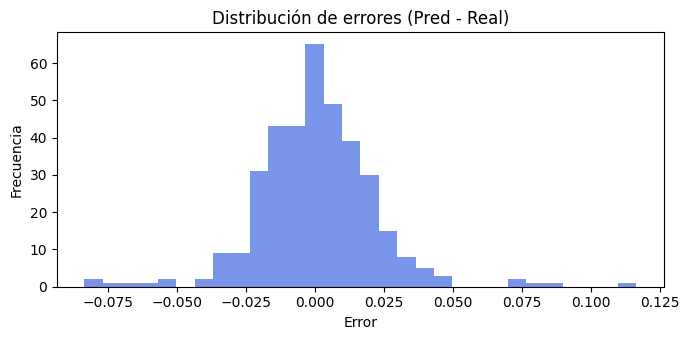

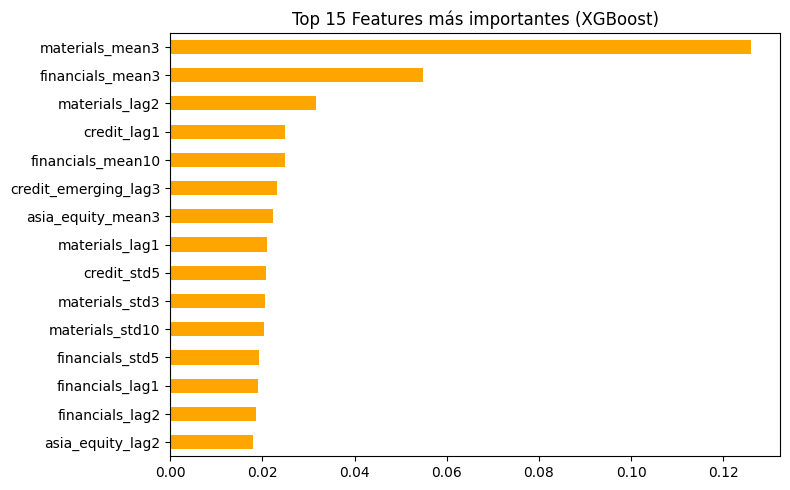

In [21]:
# Concatenamos resultados del último fold para graficar
y_pred_final = pd.Series(preds[-1], index=y.iloc[dates_idx[-1]].index)
y_true_final = y.iloc[dates_idx[-1]]

plt.figure(figsize=(10,4))
plt.plot(y_true_final.values, label="Real", linewidth=2)
plt.plot(y_pred_final.values, label="Predicho", linestyle="--")
plt.title(f"Predicción vs Real ({target_col}) — Último fold temporal")
plt.xlabel("Índice temporal")
plt.ylabel("Retorno logarítmico")
plt.legend()
plt.tight_layout()
plt.show()

# Distribución de errores
plt.figure(figsize=(7,3.5))
errors = y_pred_final.values - y_true_final.values
plt.hist(errors, bins=30, alpha=0.7, color='royalblue')
plt.title("Distribución de errores (Pred - Real)")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# Importancia de features
importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,5))
top_features[::-1].plot(kind='barh', color='orange')
plt.title("Top 15 Features más importantes (XGBoost)")
plt.tight_layout()
plt.show()
